## Импорты

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## Загрузка train/test

In [9]:
train_path = './train.csv'
test_path = './test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.shape, test_df.shape

((42000, 785), (28000, 784))

## Подготовка `X`, `y`

In [10]:
y = train_df['label'].values.astype('int64')

X = train_df.drop(columns=['label']).values.astype('float32') / 255.0
X_test = test_df.values.astype('float32') / 255.0

X.shape, y.shape, X_test.shape

((42000, 784), (42000,), (28000, 784))

## Визуализация примеров

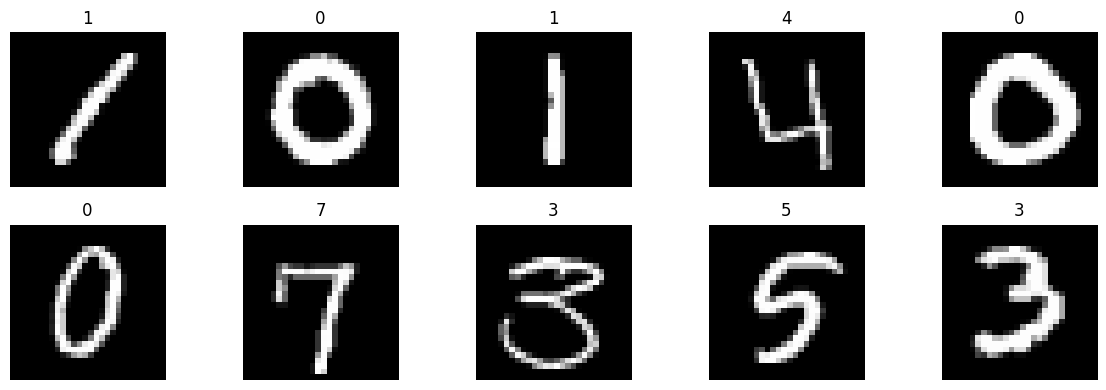

In [11]:
fig = plt.figure(figsize=(12, 4))
for i in range(10):
    ax = fig.add_subplot(2, 5, i + 1)
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y[i]))
    ax.axis('off')
plt.tight_layout()
plt.show()

## Разбиение на train/val

In [12]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_tr.shape, X_val.shape

((33600, 784), (8400, 784))

## Пайплайн: StandardScaler -> PCA -> LogisticRegression

Параметры будем подбирать по `C` (регуляризация). PCA берём по доле объяснённой дисперсии `0.95`.

In [13]:
def make_model(C):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95, random_state=42)),
        ('clf', LogisticRegression(
            C=C,
            solver='saga',
            max_iter=3000,
            n_jobs=-1
        ))
    ])

## Подбор `C` на валидации + качество

In [14]:
C_grid = [0.3, 1.0, 3.0, 10.0]

best_C = None
best_acc = -1.0
best_model = None

for C in C_grid:
    model = make_model(C)
    model.fit(X_tr, y_tr)
    pred_val = model.predict(X_val)
    acc = accuracy_score(y_val, pred_val)
    print('C:', C, 'val_accuracy:', acc)
    if acc > best_acc:
        best_acc = acc
        best_C = C
        best_model = model

best_C, best_acc

c:\Users\Misha\PycharmProjects\netology\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C: 0.3 val_accuracy: 0.9217857142857143


c:\Users\Misha\PycharmProjects\netology\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C: 1.0 val_accuracy: 0.9216666666666666


c:\Users\Misha\PycharmProjects\netology\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C: 3.0 val_accuracy: 0.9213095238095238


c:\Users\Misha\PycharmProjects\netology\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C: 10.0 val_accuracy: 0.9217857142857143


(0.3, 0.9217857142857143)

## Отчёт по валидации

In [15]:
pred_val = best_model.predict(X_val)
print('Validation accuracy:', accuracy_score(y_val, pred_val))
print(classification_report(y_val, pred_val))

Validation accuracy: 0.9217857142857143
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       827
           1       0.93      0.98      0.96       937
           2       0.93      0.91      0.92       835
           3       0.91      0.89      0.90       870
           4       0.91      0.92      0.91       814
           5       0.88      0.87      0.87       759
           6       0.96      0.97      0.97       827
           7       0.94      0.94      0.94       880
           8       0.91      0.86      0.88       813
           9       0.90      0.91      0.90       838

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400



## Обучение на всём train и предсказание test

In [16]:
final_model = make_model(best_C)
final_model.fit(X, y)

pred_test = final_model.predict(X_test)
pred_test[:10], pred_test.shape

c:\Users\Misha\PycharmProjects\netology\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


(array([2, 0, 9, 7, 3, 7, 0, 3, 0, 3]), (28000,))

## Формирование `submission.csv`

Формат Kaggle: две колонки - `ImageId` (с 1) и `Label`.

In [17]:
submission = pd.DataFrame({
    'ImageId': np.arange(1, len(pred_test) + 1),
    'Label': pred_test.astype('int64')
})

submission.to_csv('submission.csv', index=False)
submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,7
4,5,3
